# 04 · The DL regime-MoE — a learned gate for the close regime

*Edge-features arc · 01 discovery · 02 linear base · 03 hero cascade · 04 regime-MoE · 05 temporal-kNN  —  machinery: `ridge_pipeline_throughline.ipynb`*

**Verify first.** Each row is a real `resid_regime` cascade run on `linbest` with the **same d8@cs0.5
global** as ch. 03, swapping only the regime learner for an **interpretable mixture-of-experts**: a
factorization-machine **expert** (native low-rank pairwise — the EBM's winning bias as one differentiable
primitive) optionally routed by a learned soft-tree **gate** (the *automated* analog of the hand-found
`hour` regime, ch. 01). Every QLIKE below is **recomputed from the saved per-bar predictions through the
real pipeline metric** and **asserted** against the cluster collect — `ctrl_ebm` reproduces the `0.12033`
anchor so the MoE rows are comparable.

**Honest prior: low** — a tuned XGB regime already lost to the EBM (ch. 03). The likely payoff is the
**interpretable gate readout**, not the 4th-decimal QLIKE.

In [1]:
import html, inspect, json, os, sys, textwrap
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def find_repo(s):
    for q in [Path(s).resolve(), *Path(s).resolve().parents]:
        if (q / "resid_amortized.py").exists() and (q / "src").is_dir():
            return q
    raise FileNotFoundError("repo root")
REPO = find_repo(Path.cwd()); os.chdir(REPO); sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO)+'/experiments')

from src.evaluation.metrics import apply_duan_smearing  # the REAL pipeline metric

# Collapsible, theme-following source display (one <details> per object; folded).
def _details(f, open_=False):
    mod = f.__module__.replace("src.", "src/").replace(".", "/") + ".py"
    try:
        sig = ("class " + f.__name__) if inspect.isclass(f) else ("def " + f.__name__ + str(inspect.signature(f)))
    except (ValueError, TypeError):
        sig = f.__qualname__
    body = "```python\n" + textwrap.dedent(inspect.getsource(f)).rstrip() + "\n```"
    return (f"<details{' open' if open_ else ''}>\n<summary><code>{html.escape(mod + '  ·  ' + sig)}"
            f"</code></summary>\n\n{body}\n\n</details>")
def show_one(f):
    return Markdown(_details(f))

# ── the verification machinery: recompute QLIKE from saved per-bar preds ──────
# Local preds are gitignored; if absent we print the exact reproduce-command.
PREDS = REPO / "results" / "moe_ladder" / "preds"
CID = "xgb_all_buckets_tw1000_enetreg2_linbest_rf480_slim"

def recompute(label):
    """Full-OOS QLIKE recomputed from saved per-bar preds via apply_duan_smearing.
    Returns (qlike, n) if the preds csv is present, else (None, 0)."""
    fp = PREDS / f"{label}.csv"
    if not fp.exists():
        return None, 0
    df = pd.read_csv(fp)                                  # cols: k, pred_adj, y_true, base
    pr, tr = apply_duan_smearing(df.pred_adj.to_numpy(), df.y_true.to_numpy(), df.base.to_numpy())
    m = (tr > 0) & (pr > 0); r = tr[m] / pr[m]
    return float(np.mean(r - np.log(r) - 1.0)), int(len(df))

def reproduce_cmd(arm, label):
    return f"$PY resid_amortized.py chunk_collect {CID} {arm} {label}"

# cluster reference (results_all.csv) — what each RECOMPUTE must reproduce to <1e-4
REF = pd.read_csv(REPO / "results" / "moe_ladder" / "results_all.csv").set_index("label")
print("setup ok | preds present:", PREDS.exists(), "| reference rows:", len(REF))

setup ok | preds present: True | reference rows: 11


---
## 1 · The new regime learner (folded)

The cascade is unchanged; only the regime learner is new (`_tree_factory("moe", cfg)`). Two pieces folded
below: the **`FMExpert`** (factorization-machine pairwise expert — the rank IS the regularizer, the EBM's
bagged-pairwise bias as one differentiable op) and the **`SoftTreeGate`** (read its hyperplane post-fit to
recover *where* the regimes are).

In [2]:
from src.models.regime_moe import FMExpert, SoftTreeGate
display(show_one(FMExpert))      # the pairwise expert (fm_* and bfm_* rows)
display(show_one(SoftTreeGate))  # the learned routing gate (depth>0 rows)

<details>
<summary><code>src/models/regime_moe.py  ·  class FMExpert</code></summary>

```python
class FMExpert(nn.Module):
    """Factorization Machine — pairwise interactions baked in NATIVELY via low-rank factors:
        y = b + w·x + 0.5·Σ_f[(Σ_i V_if x_i)² − Σ_i V_if² x_i²]   (the FM trick, O(B·p·rank)).
    The low-rank ``rank`` IS the regularizer (vs enumerating p² pairwise shape fns) — the EBM's winning
    bias (bagged PAIRWISE) as ONE differentiable primitive, with the soft-tree gate on top. The XGB
    depth evidence (best d3, but the pairwise EBM beats it) says pairwise is the right interaction order.
    """

    def __init__(
        self,
        input_dim: int,
        rank: int = 8,
        dropout: float = 0.15,
        use_high_order_probe: bool = False,
        linear: bool = True,
    ):
        super().__init__()
        self.use_high_order_probe = use_high_order_probe
        self.use_linear = linear
        if linear:
            self.linear = nn.Linear(input_dim, 1)  # b + w·x (main-effect part)
        else:
            # pure-pairwise: base (linbest) + global tree already took the main effects; the regime
            # leftover is interactions, so model only bias + pairwise -> focuses capacity, drops p params.
            self.bias = nn.Parameter(torch.zeros(1))
        self.V = nn.Parameter(torch.randn(input_dim, rank) * 0.01)  # low-rank pairwise factors
        self.dropout = nn.Dropout(dropout)
        if use_high_order_probe:
            self.high_order_mlp = nn.Sequential(
                nn.Linear(input_dim, 32),
                nn.LayerNorm(32),
                nn.SiLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.dropout(x)
        lin = self.linear(x) if self.use_linear else self.bias  # [B,1] or broadcast bias
        xv = x @ self.V  # [B, rank]
        x2v2 = (x * x) @ (self.V * self.V)  # [B, rank]
        pair = 0.5 * (xv.pow(2) - x2v2).sum(dim=1, keepdim=True)  # [B, 1] — all pairwise interactions
        out = lin + pair
        if self.use_high_order_probe:
            return out + self.high_order_mlp(x)
        return out
```

</details>

<details>
<summary><code>src/models/regime_moe.py  ·  class SoftTreeGate</code></summary>

```python
class SoftTreeGate(nn.Module):
    """Hierarchical soft partition. Each internal node is a linear hyperplane
    ``P(left) = sigmoid(W x + b)``; leaf weight = product of branch probabilities
    along its root->leaf path. Post-fit the node weights are the human-readable
    regime hyperplanes (the automated corr-by-hour localization).

    General depth: reduces bit-for-bit to the depth-1/2 scaffold but supports any
    depth so the partition can scale "only if it earns it".
    """

    def __init__(self, input_dim: int, depth: int = 1):
        super().__init__()
        if depth < 1:
            raise ValueError("SoftTreeGate needs depth >= 1 (depth 0 = no gate)")
        self.depth = depth
        self.num_leaves = 2**depth
        self.num_nodes = 2**depth - 1
        # one hyperplane per internal node; node ordering is heap order (root=0)
        self.decision_nodes = nn.Linear(input_dim, self.num_nodes)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        decisions = torch.sigmoid(self.decision_nodes(x))  # [B, num_nodes] = P(left)
        # Walk the tree level by level: each frontier entry carries (path prob, node idx).
        leaf_probs = [(torch.ones_like(decisions[:, 0]), 0)]
        for _ in range(self.depth):
            nxt: list[tuple[torch.Tensor, int]] = []
            for prob, node in leaf_probs:
                p_left = decisions[:, node]
                nxt.append((prob * p_left, 2 * node + 1))  # left child
                nxt.append((prob * (1.0 - p_left), 2 * node + 2))  # right child
            leaf_probs = nxt
        p_leaves = torch.stack([p for p, _ in leaf_probs], dim=1)  # [B, num_leaves]

        # Load-balancing aux loss: penalize uneven leaf utilization (anti-collapse).
        mean_routing = p_leaves.mean(dim=0)
        var_routing = p_leaves.var(dim=0)
        load_balance = (var_routing / (mean_routing**2 + 1e-8)).mean()
        return p_leaves, load_balance
```

</details>

**The rest of the regime learner the ladder configures (folded).** `FMExpert` / `SoftTreeGate` above are the two highlighted pieces; the remaining three objects each sit behind a rung in §2, so each is framed by the row it produces.

The additive **`sat_d0`** rung at the top of the ladder (input-saturation, **no interactions**, lands far above the bar at `0.12757`) is a single `NAMExpert` with `depth=0`:

<details>
<summary><code>src/models/regime_moe.py  ::  NAMExpert</code></summary>

```python
class NAMExpert(nn.Module):
    """Neural additive model. Grouped 1D convolutions learn one isolated shape
    function per feature in a single kernel (no Python feature loop). Optional
    high-order MLP head is the DIAGNOSTIC probe for >=3-way interactions."""

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 16,
        dropout: float = 0.3,
        use_high_order_probe: bool = False,
    ):
        super().__init__()
        self.use_high_order_probe = use_high_order_probe
        # isolated per-feature shapes via groups=input_dim (zero cross-talk)
        self.layer1 = nn.Conv1d(input_dim, input_dim * hidden_dim, 1, groups=input_dim)
        self.activation = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
        self.layer2 = nn.Conv1d(input_dim * hidden_dim, input_dim, 1, groups=input_dim)
        self.bias = nn.Parameter(torch.zeros(1))
        if use_high_order_probe:
            self.high_order_mlp = nn.Sequential(
                nn.Linear(input_dim, 32),
                nn.LayerNorm(32),
                nn.SiLU(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.layer1(x.unsqueeze(2))  # [B, input_dim, 1] -> [B, input_dim*hidden, 1]
        h = self.dropout(self.activation(h))
        contributions = self.layer2(h)  # [B, input_dim, 1]
        out = (self.bias + contributions.sum(dim=1).squeeze(-1)).unsqueeze(1)  # [B, 1]
        if self.use_high_order_probe:
            return out + self.high_order_mlp(x)
        return out
```

</details>

The gated rungs — `fm_d1`/`fm_d2`, the `depth>0` routing rows that buy the small monotone gain — come from the gate↔expert fusion in one forward pass; `depth=0` degenerates to one global expert (the no-gate `fm_d0`/`bfm_d0` rows):

<details>
<summary><code>src/models/regime_moe.py  ::  InterpretableRegimeMoE</code></summary>

```python
class InterpretableRegimeMoE(nn.Module):
    """Learned soft regimes -> interpretable NAM experts -> optional per-regime
    high-order diagnostic. depth=0 degenerates to one global NAM (EBM-equivalent)."""

    def __init__(
        self,
        input_dim: int,
        depth: int = 1,
        hidden_dim: int = 16,
        dropout: float = 0.3,
        use_diagnostic_mlp: bool = False,
        expert: str = "fm",
        rank: int = 8,
        fm_linear: bool = True,
        gate_kind: str = "tree",
        num_regimes: int = 4,
        gate_input_dim: int | None = None,
        gate_temp: float = 1.0,
    ):
        super().__init__()
        self.gate_kind = gate_kind
        self.film = gate_kind == "film"
        if self.film:  # continuous context modulation instead of discrete routing (one shared expert)
            self.is_baseline = False
            cdim = input_dim if gate_input_dim is None else gate_input_dim
            self.film_expert = FiLMExpert(input_dim, cdim, rank, fm_linear, hidden_dim, dropout)
            return
        self.is_baseline = depth == 0
        if self.is_baseline:
            self.num_experts = 1
        elif gate_kind == "attention":  # K prototype regimes (not a 2^depth tree)
            self.num_experts = num_regimes
        else:
            self.num_experts = 2**depth

        def _mk_expert():
            if expert == "fm":  # native low-rank pairwise (the EBM-matching interaction order)
                return FMExpert(input_dim, rank, dropout, use_diagnostic_mlp, fm_linear)
            return NAMExpert(input_dim, hidden_dim, dropout, use_diagnostic_mlp)

        self.experts = nn.ModuleList([_mk_expert() for _ in range(self.num_experts)])
        if not self.is_baseline:
            gdim = input_dim if gate_input_dim is None else gate_input_dim  # #2: gate context may differ
            self.gate = (
                AttentionGate(gdim, num_regimes, temperature=1.0 / gate_temp)  # >1 sharpens
                if gate_kind == "attention"
                else SoftTreeGate(gdim, depth, temperature=gate_temp)
            )

    def forward(
        self, x: torch.Tensor, x_gate: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        if self.film:  # continuous modulation by context (no routing, no load-balance aux)
            return self.film_expert(x, x if x_gate is None else x_gate), x.new_zeros(())
        expert_outputs = torch.cat([e(x) for e in self.experts], dim=1)  # [B, K]
        if self.is_baseline:
            return expert_outputs, x.new_zeros(())
        routing, aux = self.gate(x if x_gate is None else x_gate)  # #2: gate may route on SEPARATE context
        y_resid = torch.sum(routing * expert_outputs, dim=-1, keepdim=True)
        return y_resid, aux
```

</details>

Every rung in §2 is one `cfg` into the sklearn-style wrapper `_tree_factory("moe", cfg)` builds — z-scale → optional hinge basis-expand → bagged fit of the gate+experts → soft-routed predict:

<details>
<summary><code>src/models/regime_moe.py  ::  RegimeMoE</code></summary>

```python
class RegimeMoE:
    """``.fit(X, y)`` / ``.predict(X)`` wrapper around :class:`InterpretableRegimeMoE`.

    Standardizes inputs (and optionally the residual target) on train stats, carves
    a temporal val tail for early stopping, trains with AdamW + load-balance aux,
    and restores best-val weights. Heavy weight decay + dropout + early stop for the
    few-thousand-row, ~93%-noise h16-19 leftover.
    """

    def __init__(
        self,
        depth: int = 1,
        hidden_dim: int = 16,
        dropout: float = 0.15,
        n_bags: int = 8,
        colsample: float = 0.5,
        expert: str = "fm",
        rank: int = 8,
        fm_linear: bool = True,
        wd_v: float | None = None,
        basis: str = "none",
        n_knots: int = 3,
        gate_kind: str = "tree",
        num_regimes: int = 4,
        gate_context: str = "expert",
        gate_temp: float = 1.0,
        epochs: int = 150,
        lr: float = 1e-3,
        gate_lr: float | None = None,
        weight_decay: float = 1e-1,
        gate_weight_decay: float | None = None,
        aux_weight: float = 0.5,
        use_diagnostic_mlp: bool = False,
        val_frac: float = 0.2,
        patience: int = 12,
        min_val_rows: int = 64,
        scale_y: bool = True,
        device: str | None = None,
        seed: int = 42,
    ):
        self.depth = depth
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        self.n_bags = n_bags
        self.colsample = colsample
        self.expert = expert
        self.rank = rank
        self.fm_linear = fm_linear
        self.wd_v = wd_v
        self.basis = basis
        self.n_knots = n_knots
        self.gate_kind = gate_kind
        self.num_regimes = num_regimes
        self.gate_context = gate_context
        self.gate_temp = gate_temp
        self.epochs = epochs
        self.lr = lr
        # the gate's routing direction (W) must TRAIN to point at a useful axis; full-batch + early stop
        # gives it few steps. gate_lr > lr lets W find its direction faster within the val-improving window.
        self.gate_lr = gate_lr
        self.weight_decay = weight_decay
        # decouple the gate's routing hyperplanes from the experts' heavy decay: the wd that stops the
        # FM experts overfitting the noisy h16-19 sample ALSO shrinks the gate's W -> sigmoid/softmax -> uniform
        # routing (a second gate-suppressor beside the load-balance term). None -> share weight_decay (legacy).
        self.gate_weight_decay = gate_weight_decay
        self.aux_weight = aux_weight
        self.use_diagnostic_mlp = use_diagnostic_mlp
        self.val_frac = val_frac
        self.patience = patience
        self.min_val_rows = min_val_rows
        self.scale_y = scale_y
        self.device = torch.device(
            device or ("cuda" if torch.cuda.is_available() else "cpu")
        )
        self.seed = seed

    # standardization helpers: scale from dispersion-carrying obs; constant
    # columns pass through centered (no arbitrary epsilon).
    def _fit_scaler(self, X: np.ndarray) -> None:
        self._x_mean = X.mean(axis=0, keepdims=True)
        std = X.std(axis=0, keepdims=True)
        self._x_std = np.where(std > 0, std, 1.0)
        if self.scale_y:
            self._y_mean = float(self._y.mean())
            ys = float(self._y.std())
            self._y_std = ys if ys > 0 else 1.0
        else:
            self._y_mean, self._y_std = 0.0, 1.0

    def _xz(self, X: np.ndarray) -> np.ndarray:
        return (X - self._x_mean) / self._x_std

    def _basis_expand(self, Xz: np.ndarray) -> np.ndarray:
        """Quantile-knot HINGE basis: per feature [x, relu(x-q1), .., relu(x-qm)]. The linear combo of
        hinges = a piecewise-linear 1D shape; the FM's bilinear of two hinge-bases = a flexible 2D
        interaction -> a differentiable GA2M (EBM-style shapes). Threshold-mixture form; knots are
        data-adaptive quantiles (no magic). basis != "hinge" -> identity."""
        if self.basis != "hinge":
            return Xz
        cols = [Xz]
        for k in range(self.n_knots):
            cols.append(np.maximum(Xz - self._knots[:, k], 0.0))
        return np.concatenate(cols, axis=1).astype(np.float32)

    def _train_one(self, Xtr, ytr, Xva, yva, p, bag_seed, use_val, Xtr_g=None, Xva_g=None):
        """Train one bag to its best-val weights. Xtr_g/Xva_g = separate gate-routing context (#2)."""
        torch.manual_seed(bag_seed)
        model = InterpretableRegimeMoE(
            input_dim=p,
            depth=self.depth,
            hidden_dim=self.hidden_dim,
            dropout=self.dropout,
            use_diagnostic_mlp=self.use_diagnostic_mlp,
            expert=self.expert,
            rank=self.rank,
            fm_linear=self.fm_linear,
            gate_kind=self.gate_kind,
            num_regimes=self.num_regimes,
            gate_input_dim=(None if Xtr_g is None else Xtr_g.shape[1]),
            gate_temp=self.gate_temp,
        ).to(self.device)
        # separate (stronger) L2 on the FM factors V than the rest: the pairwise factors are where FM
        # overfitting lives, so uniform decay under-regularizes the interactions. wd_v=None -> uniform.
        wd_v = self.weight_decay if self.wd_v is None else self.wd_v
        gate_wd = self.weight_decay if self.gate_weight_decay is None else self.gate_weight_decay
        # the "gate" group = the routing/modulation params (SoftTreeGate/AttentionGate OR the FiLM head),
        # so gate_lr/gate_weight_decay tune the context mechanism independently of the experts.
        def _is_gate(nm):
            return nm.startswith("gate.") or ".film." in nm

        v_params = [prm for nm, prm in model.named_parameters() if nm.endswith(".V")]
        gate_params = [prm for nm, prm in model.named_parameters() if _is_gate(nm)]
        other = [
            prm
            for nm, prm in model.named_parameters()
            if not nm.endswith(".V") and not _is_gate(nm)
        ]
        gate_lr = self.lr if self.gate_lr is None else self.gate_lr
        opt = torch.optim.AdamW(
            [
                {"params": other, "weight_decay": self.weight_decay},
                {"params": v_params, "weight_decay": wd_v},
                {"params": gate_params, "weight_decay": gate_wd, "lr": gate_lr},
            ],
            lr=self.lr,
        )
        mse = nn.MSELoss()
        best_val, best_state, wait = float("inf"), None, 0
        for _ in range(self.epochs):
            model.train()
            opt.zero_grad(set_to_none=True)
            pred, aux = model(Xtr, Xtr_g)
            (mse(pred, ytr) + self.aux_weight * aux).backward()
            opt.step()
            model.eval()
            with torch.no_grad():
                vloss = mse(model(Xva, Xva_g)[0], yva).item()
            if vloss < best_val:
                best_val, wait = vloss, 0
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            elif use_val:
                wait += 1
                if wait >= self.patience:
                    break
        if best_state is not None:
            model.load_state_dict(best_state)
        return model

    def fit(self, X: np.ndarray, y: np.ndarray) -> RegimeMoE:
        X = np.ascontiguousarray(X, dtype=np.float32)
        self._y = np.ascontiguousarray(y, dtype=np.float32).ravel()
        n, p = X.shape
        self._fit_scaler(X)
        Xz = self._xz(X)
        # per-feature INPUT saturation: clamp each standardized feature to its train [min,max] so every
        # shape function goes FLAT outside the observed support — exactly like an EBM bin (the EBM's real
        # inductive bias). Bounded-by-construction at the FUNCTION level (not an aggregate output clamp);
        # this is what stops the unbounded-SiLU extrapolation that blew up the Duan smear (moe_d0=0.152).
        # No-op on the training rows (they define the range); it only bites OOS extremes at predict.
        self._xz_lo = Xz.min(axis=0, keepdims=True)
        self._xz_hi = Xz.max(axis=0, keepdims=True)
        Xz = np.clip(Xz, self._xz_lo, self._xz_hi).astype(np.float32)
        Xz_raw = Xz  # raw standardized+saturated features = the gate context when decoupled (#2)
        if self.basis == "hinge":  # quantile-knot hinge basis -> nonlinear shapes + 2D interactions
            qs = np.linspace(0.0, 1.0, self.n_knots + 2)[1:-1]  # interior quantiles e.g. [.25,.5,.75]
            self._knots = np.quantile(Xz, qs, axis=0).T  # [p, n_knots], data-adaptive knots
            Xz = self._basis_expand(Xz)
        p = Xz.shape[1]  # basis expansion changes the working feature width
        yz = ((self._y - self._y_mean) / self._y_std).astype(np.float32)

        # temporal val tail (chronological); bootstrap the train pool per bag (bagging =
        # the EBM's variance control a single per-block NAM lacked).
        n_val = int(round(self.val_frac * n))
        use_val = n_val >= self.min_val_rows and (n - n_val) >= self.min_val_rows
        n_tr = (n - n_val) if use_val else n
        dev = self.device
        Xt = torch.as_tensor(Xz, device=dev)
        yt = torch.as_tensor(yz, device=dev).unsqueeze(1)
        Xva = Xt[n_tr:n] if use_val else Xt
        yva = yt[n_tr:n] if use_val else yt
        # #2 context decoupling: route the gate on the FULL raw features (not basis-expanded, not feature-
        # subsampled) while experts use their (basis-expanded, subsampled) inputs. gate_context!=raw -> coupled.
        Xt_g = torch.as_tensor(Xz_raw, device=dev) if self.gate_context == "raw" else None
        Xva_g = (Xt_g[n_tr:n] if use_val else Xt_g) if Xt_g is not None else None

        rng = np.random.default_rng(self.seed)
        n_sub = max(1, int(round(self.colsample * p)))
        self.models_ = []
        for b in range(self.n_bags):
            # bootstrap ROWS + subsample FEATURES per bag -> decorrelated bags (the RF trick), the
            # strongest variance reducer for this small, noise-dominated, high-dim regime sample.
            ridx = torch.as_tensor(rng.integers(0, n_tr, size=n_tr), device=dev)
            fcols = np.sort(rng.choice(p, size=n_sub, replace=False))
            fidx = torch.as_tensor(fcols, device=dev)
            gtr = Xt_g[ridx] if Xt_g is not None else None  # gate sees the FULL context (not subsampled)
            model = self._train_one(
                Xt[ridx][:, fidx], yt[ridx], Xva[:, fidx], yva, n_sub, self.seed + b, use_val, gtr, Xva_g
            )
            self.models_.append((model, fidx))
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.ascontiguousarray(X, dtype=np.float32)
        # per-feature saturation: hold OOS-extreme features at the train boundary -> shape fns saturate
        Xz = np.clip(self._xz(X), self._xz_lo, self._xz_hi).astype(np.float32)
        Xz_raw = Xz
        Xz = self._basis_expand(Xz)  # apply the fitted basis (no-op if basis="none")
        Xt = torch.as_tensor(Xz, device=self.device)
        Xt_g = torch.as_tensor(Xz_raw, device=self.device) if self.gate_context == "raw" else None
        with torch.no_grad():
            preds = []
            for m, fidx in self.models_:  # each bag uses its own feature subset
                m.eval()
                preds.append(m(Xt[:, fidx], Xt_g)[0])  # gate routes on the full decoupled context (#2)
            pred = torch.stack(preds, 0).mean(0).squeeze(1)
            if os.environ.get("MOE_DIAG") and self.depth > 0:
                self._print_routing_diag(Xt, Xt_g)
        return (pred.cpu().numpy() * self._y_std + self._y_mean).astype(np.float64)

    def _print_routing_diag(self, Xt: torch.Tensor, Xt_g: torch.Tensor | None) -> None:
        """Gate-LIVENESS probe (the H1 test): is the gate actually routing, or pinned ~uniform?
        Per bag, recompute routing on the predict set and report, averaged over bags:
          Hnorm = mean per-sample entropy / log K  (1.0 = uniform = INERT; <<1 = confident routing)
          wstd  = mean across experts of each expert's BETWEEN-sample routing std (0 = sample-invariant)
          util_max/min = mean utilization spread (load balance); decisive = frac of rows with max-w > 0.5
        Aggregate QLIKE cannot distinguish a suppressed gate from an unhelpful one; this can."""
        if getattr(self.models_[0][0], "film", False):  # FiLM: report modulation magnitude + context-variation
            amp, cstd = [], []
            with torch.no_grad():
                for m, fidx in self.models_:
                    c = Xt[:, fidx] if Xt_g is None else Xt_g
                    gamma = 1.0 + m.film_expert.film(c)  # [B, rank]
                    amp.append(float((gamma - 1.0).abs().mean()))  # distance from plain FM (gamma=1)
                    cstd.append(float(gamma.std(dim=0).mean()))  # how much modulation VARIES with context
            print(
                f"MOE_DIAG FiLM mod_amp={np.mean(amp):.4f} mod_ctxstd={np.mean(cstd):.4f} "
                f"(amp=0 & ctxstd=0 => modulation OFF = plain FM)",
                flush=True,
            )
            return
        Hn, ws, umx, umn, dec, K = [], [], [], [], [], None
        with torch.no_grad():
            for m, fidx in self.models_:
                gx = Xt[:, fidx] if Xt_g is None else Xt_g
                r, _ = m.gate(gx)  # [B, K]
                K = r.size(1)
                p = r.clamp_min(1e-12)
                Hn.append(float((-(p * p.log()).sum(1).mean()) / np.log(K)))
                ws.append(float(r.std(dim=0).mean()))
                u = r.mean(0)
                umx.append(float(u.max()))
                umn.append(float(u.min()))
                dec.append(float((r.max(1).values > 0.5).float().mean()))
        print(
            f"MOE_DIAG K={K} Hnorm={np.mean(Hn):.4f} wstd={np.mean(ws):.4f} "
            f"util_max={np.mean(umx):.4f} util_min={np.mean(umn):.4f} decisive_frac={np.mean(dec):.4f}",
            flush=True,
        )
```

</details>

---
## 2 · Verify — the expressivity ladder, recomputed

`submit_moe_chain.sh` → `results/moe_ladder/preds/<label>.csv` (per-bar `pred_adj, y_true, base`). Each
row reloads its preds and runs the **exact** pipeline QLIKE on them (`apply_duan_smearing`, folded), then
**asserts** the recompute matches the cluster `results_all.csv` to `<1e-4`. **`ctrl_ebm` must reproduce
`0.12033`** — the anchor that makes the MoE rows comparable.

In [3]:
show_one(apply_duan_smearing)   # the real metric — folded, recomputed below

<details>
<summary><code>src/evaluation/metrics.py  ·  def apply_duan_smearing(forecasts: &#x27;np.ndarray&#x27;, y_true: &#x27;np.ndarray&#x27;, baselines: &#x27;np.ndarray&#x27;) -&gt; &#x27;tuple[np.ndarray, np.ndarray]&#x27;</code></summary>

```python
def apply_duan_smearing(
    forecasts: np.ndarray,
    y_true: np.ndarray,
    baselines: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Apply Duan smearing correction to convert adjusted-scale forecasts to raw scale.

    Parameters
    ----------
    forecasts : array-like
        Model predictions on adjusted (sqrt / log) scale.
    y_true : array-like
        True values on adjusted scale.
    baselines : array-like
        Baseline volatility used to scale back to raw units.

    Returns
    -------
    pred_raw : np.ndarray
        Smearing-corrected predictions on raw scale.
    true_raw : np.ndarray
        True values on raw scale.
    """
    forecasts = np.asarray(forecasts, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.float64)
    baselines = np.asarray(baselines, dtype=np.float64)

    smear = np.mean((y_true - forecasts) ** 2)
    pred_raw = (forecasts**2 + smear) * baselines
    true_raw = (y_true**2) * baselines
    return pred_raw, true_raw
```

</details>

,rung,qlike,d_vs_EBM,n,source,desc
0,ctrl_ebm,0.12033,0.00000,194934,RECOMPUTE,EBM regime — the bar (additive+pairwise+bagging)
1,sat_d0,0.12757,0.00724,194934,RECOMPUTE,additive NAM (input-saturation) — NO interactions
2,fm_d0_wd10,0.12108,0.00075,194934,RECOMPUTE,"plain bilinear FM, no gate"
3,fm_d1_wd10,0.12098,0.00065,194934,RECOMPUTE,plain bilinear FM + depth-1 gate (2 regimes)
4,fm_d2_wd10,0.12091,0.00058,194934,RECOMPUTE,plain bilinear FM + depth-2 gate (4 regimes)
5,bfm_d0_pure,0.12080,0.00047,194934,RECOMPUTE,"hinge basis-FM — nonlinear pairwise, no gate (..."


PASS — every rung reproduces its cluster QLIKE to <1e-4; ctrl_ebm anchors the bar at 0.12033.


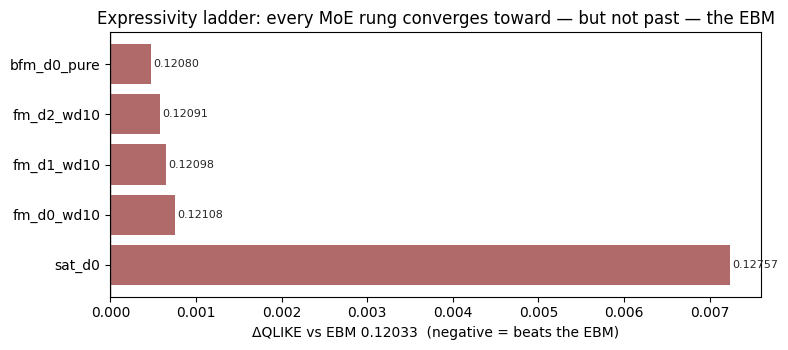

In [4]:
# expressivity ladder — additive → bilinear-pairwise (+gate) → nonlinear-pairwise.  ALL recomputed.
RUNGS = [
    ("ctrl_ebm",    "EBM regime — the bar (additive+pairwise+bagging)"),
    ("sat_d0",      "additive NAM (input-saturation) — NO interactions"),
    ("fm_d0_wd10",  "plain bilinear FM, no gate"),
    ("fm_d1_wd10",  "plain bilinear FM + depth-1 gate (2 regimes)"),
    ("fm_d2_wd10",  "plain bilinear FM + depth-2 gate (4 regimes)"),
    ("bfm_d0_pure", "hinge basis-FM — nonlinear pairwise, no gate (= no-regime)"),
]
EBM = recompute("ctrl_ebm")[0]
rows = []
for lbl, desc in RUNGS:
    q, n = recompute(lbl)
    assert q is not None, f"{lbl}: preds missing — reproduce with  {reproduce_cmd('resid_regime', lbl)}"
    ref = float(REF.loc[lbl, "qlike_full"])
    assert abs(q - ref) < 1e-4, f"{lbl}: RECOMPUTE {q:.5f} != cluster {ref:.5f}"
    rows.append({"rung": lbl, "qlike": round(q, 5), "d_vs_EBM": round(q - EBM, 5),
                 "n": n, "source": "RECOMPUTE", "desc": desc})

assert abs(EBM - 0.12033) < 5e-4, f"ctrl_ebm {EBM:.5f} did NOT reproduce 0.12033 — path suspect"
tab = pd.DataFrame(rows)
display(tab[["rung", "qlike", "d_vs_EBM", "n", "source", "desc"]])
print(f"PASS — every rung reproduces its cluster QLIKE to <1e-4; ctrl_ebm anchors the bar at {EBM:.5f}.")

plot = tab[tab.rung != "ctrl_ebm"].sort_values("d_vs_EBM", ascending=False)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(plot.rung, plot.d_vs_EBM, color=["#b06a6a" if d > 0 else "#2f6f4e" for d in plot.d_vs_EBM])
ax.axvline(0, c="0.3", lw=1)
ax.set_xlabel("ΔQLIKE vs EBM 0.12033  (negative = beats the EBM)")
ax.set_title("Expressivity ladder: every MoE rung converges toward — but not past — the EBM")
for y, (d, q) in enumerate(zip(plot.d_vs_EBM, plot.qlike)):
    ax.text(d + (3e-5 if d >= 0 else -3e-5), y, f"{q:.5f}", va="center",
            ha="left" if d >= 0 else "right", fontsize=8, color="0.15")
plt.tight_layout(); plt.show()

**The cluster cascade that produced every per-bar pred above (folded).** The QLIKE rows are recomputed *locally* from the saved `pred_adj` CSVs, but those CSVs were written by the **CARC linbest run** (`resid_amortized.py chunk_collect`, cluster-only cache) — *values from the cluster run, source shown here.* Two objects produced them, each framed by what it contributes.

The regime learner each rung selects is dispatched here: `_tree_factory("moe", cfg)` returns the `RegimeMoE` above, `"ebm"` returns the ch.-03 bar — so swapping a §2 rung is swapping this one branch:

<details>
<summary><code>resid_amortized.py  ::  _tree_factory</code></summary>

```python
def _tree_factory(model, cfg):
    if model in ("lgbm", "lightgbm"):
        from lightgbm import LGBMRegressor

        kw = dict(cfg)
        kw.setdefault("n_jobs", 4)
        kw.setdefault("verbose", -1)
        kw.setdefault("random_state", 42)
        return lambda: LGBMRegressor(**kw)
    if (
        model == "ebm"
    ):  # Microsoft EBM: bagged boosted GAM (additive + pairwise), interpretable
        from interpret.glassbox import ExplainableBoostingRegressor

        kw = dict(cfg)
        kw.setdefault("n_jobs", 4)
        kw.setdefault("random_state", 42)
        return lambda: ExplainableBoostingRegressor(**kw)
    if (
        model == "moe"
    ):  # interpretable regime mixture-of-experts (learned soft-tree gate + NAM experts)
        from src.models.regime_moe import RegimeMoE

        return lambda: RegimeMoE(**dict(cfg))
    from xgboost import XGBRegressor

    kw = dict(cfg)
    kw.setdefault("n_jobs", 4)
    kw.setdefault("tree_method", "hist")
    kw.setdefault("random_state", 42)
    return lambda: XGBRegressor(**kw)
```

</details>

And the cascade that loops it per cadence block — linbest base + per-block d8 global XGB on the survivors, then the gated regime learner on the h16-19 leftover (`resid_regime` arm) — is what wrote each per-bar `pred_adj` row recomputed above:

<details>
<summary><code>resid_amortized.py  ::  preds_chunk</code></summary>

```python
def preds_chunk(cache, arm, cfg, blk0, blk1):
    """Residualized OOS preds for the rows covered by cadence blocks [blk0, blk1).

    Chunks partition the cadence blocks, so each tree-refit point is fit in exactly ONE
    chunk (no repeated work) and the trial's full preds are the ordered concat of chunks.
    Returns (k0, k1, preds) with k = t - train_win (OOS index)."""
    c = cache
    tw = c["cell"]["train_win"]
    model = c["cell"]["model"]
    n = len(c["Xs"])
    starts = c["starts"]
    k0 = int(starts[blk0]) - tw
    k1 = (int(starts[blk1]) if blk1 < len(starts) else n) - tw
    if arm == "ridge_alone":
        return k0, k1, np.array(c["ridge_oos"][k0:k1], copy=True)
    if arm == "resid_regime":
        # Hero B regime cascade, per cadence block i:
        #   out = base_oos + GLOBAL_tree(survivors) + gated REGIME_tree(leftover, h16-19 only)
        # GLOBAL stage = Hero-A winning XGB (env GLOBAL_CFG) on the resid_subset survivors masks[i],
        # fit on r1 = y_train - base_train (the residualized target). REGIME stage = EBM (env
        # REGIME_CFG) on the LEFTOVER r2 = r1 - global(Xtr), trained on h16-19 TRAIN rows only and
        # predicting ZERO outside h16-19. With REGIME_CFG empty ({} / unset) the regime stage is
        # skipped, so this arm reproduces the single-pass resid_subset number (SANITY invariant --
        # given the resid_subset run uses the SAME xgb cfg as GLOBAL_CFG on an xgb cell).
        if "masks" not in c:
            raise KeyError(
                "resid_regime needs per-block enet survivor masks (run enet_masks first)"
            )
        if c.get("feats") is None:
            raise KeyError(
                "resid_regime needs aligned feats (cell feats.json) for the hour gate"
            )
        out = np.array(c["ridge_oos"][k0:k1], copy=True)
        masks = c["masks"]
        fm = c.get(
            "force_mask"
        )  # FORCE_COLS: union into survivors so the tree/EBM see them
        hr = c["Xs"][:, c["feats"].index("hour")]
        re = c.get(
            "regime_extra"
        )  # REGIME_EXTRA: regime-persistence features injected into the EBM ONLY -- they BYPASS the
        # global enet base (unchanged ridge_oos/coefs) and the global d8 tree (g fits survivors only),
        # entering at the regime stage where there is no global alpha to mis-penalize them. None -> off.
        gcfg = json.loads(os.environ.get("GLOBAL_CFG", "{}"))
        rcfg = json.loads(os.environ.get("REGIME_CFG", "{}"))
        # regime-stage learner: default EBM (interpretable); REGIME_MODEL=xgb -> tuned XGB for PURE
        # POWER (drops the EBM additive/pairwise constraint = the QLIKE ceiling, no interpretability).
        rmodel = os.environ.get("REGIME_MODEL", "ebm")
        regime_full = os.environ.get("REGIME_FULL", "0") not in ("", "0")  # FREE the gate (#1): fit/predict
        # on ALL hours so the learned MoE gate discovers the regime, vs the hand h16-19 pre-gate (default).
        # REGIME_INVERT (#3, structural-starvation test): swap the cascade order to REGIME-then-global, so
        # the soft-routing MoE gets FIRST crack at the un-starved r1 = y - base and d8 only soaks up its
        # leftover. Default (off) = global-then-regime (d8 eats the X-routable structure -> gate starved).
        invert = os.environ.get("REGIME_INVERT", "0") not in ("", "0")
        # REGIME_NOGLOBAL: drop the d8 global stage entirely -> base + regime ONLY (the purest un-starved
        # cascade: additive base + gate-as-sole-regime, no hard router competing). Only honored with invert.
        skip_global = os.environ.get("REGIME_NOGLOBAL", "0") not in ("", "0")
        hr_idx = c["feats"].index("hour")
        mk_g = _tree_factory("xgb", gcfg)
        for i in range(blk0, blk1):
            t_r = int(starts[i])
            cols = masks[i] if fm is None else (masks[i] | fm)
            Xtr = c["Xs"][t_r - tw : t_r]
            t_end = int(starts[i + 1]) if i + 1 < len(starts) else n
            r1 = c["y"][t_r - tw : t_r] - (Xtr @ c["coefs"][i] + c["intercepts"][i])
            if invert:  # REGIME FIRST on the un-starved r1 (gate's first crack), then d8 mops up the leftover
                Xblk = c["Xs"][t_r:t_end][:, cols]
                m_tr = _close_mask(hr[t_r - tw : t_r])
                pe_tr = np.zeros_like(r1)
                if rcfg and (regime_full or int(m_tr.sum()) >= 50):
                    cols_e = cols
                    if regime_full:
                        cols_e = cols.copy()
                        cols_e[hr_idx] = True
                    Xtr_e = Xtr[:, cols_e]
                    Xblk_e = c["Xs"][t_r:t_end][:, cols_e]
                    if re is not None:
                        Xtr_e = np.hstack([Xtr_e, re[t_r - tw : t_r]])
                        Xblk_e = np.hstack([Xblk_e, re[t_r:t_end]])
                    e = _tree_factory(rmodel, rcfg)()
                    if regime_full:
                        e.fit(Xtr_e, r1)
                        out[t_r - tw - k0 : t_end - tw - k0] += e.predict(Xblk_e).ravel()
                        pe_tr = e.predict(Xtr_e).ravel()
                    else:
                        e.fit(Xtr_e[m_tr], r1[m_tr])
                        pe = e.predict(Xblk_e).ravel()
                        pe[~_close_mask(hr[t_r:t_end])] = 0.0
                        out[t_r - tw - k0 : t_end - tw - k0] += pe
                        pe_tr = e.predict(Xtr_e).ravel()
                        pe_tr[~m_tr] = 0.0
                if not skip_global:  # d8 soaks up the regime leftover (off -> base + regime only)
                    g = mk_g()
                    g.fit(Xtr[:, cols], r1 - pe_tr)
                    out[t_r - tw - k0 : t_end - tw - k0] += g.predict(Xblk).ravel()
                continue
            g = mk_g()
            g.fit(Xtr[:, cols], r1)
            Xblk = c["Xs"][t_r:t_end][:, cols]
            out[t_r - tw - k0 : t_end - tw - k0] += g.predict(Xblk).ravel()
            if (
                not rcfg
            ):  # regime stage disabled -> single-pass resid_subset (sanity invariant)
                continue
            m_tr = _close_mask(hr[t_r - tw : t_r])
            if (
                not regime_full and int(m_tr.sum()) < 50
            ):  # too few close/AH train rows -> skip regime this block (predict 0)
                continue
            r2 = r1 - g.predict(Xtr[:, cols]).ravel()
            cols_e = cols
            if regime_full:  # add `hour` so the freed gate can route on the clock itself
                cols_e = cols.copy()
                cols_e[hr_idx] = True
            Xtr_e = Xtr[:, cols_e]
            Xblk_e = c["Xs"][t_r:t_end][:, cols_e]
            if re is not None:  # regime model also sees the persistence extras (global g unaffected above)
                Xtr_e = np.hstack([Xtr_e, re[t_r - tw : t_r]])
                Xblk_e = np.hstack([Xblk_e, re[t_r:t_end]])
            if rmodel == "ebm_mtfm":
                # EBM (+) multi-task-FM ENSEMBLE: the binned-bagged EBM on r2 plus an un-starved multi-task
                # FM (aux head predicts r1, the pre-d8 residual). They are DIVERSE (pre-check corr ~0.34) so
                # the weighted average can beat the EBM alone. ENS_W = weight on the EBM; MT_* = the FM knobs.
                from src.models.regime_moe import MultiTaskFM

                ens_w = float(os.environ.get("ENS_W", "0.4"))
                # un-starve the ANTICIPATION: MT_GATE=ghat -> per-row aux weight gated by |ghat|=|r1-r2|
                # (d8's bite, the taken structure made explicit) — spend the aux where d8 took a big bite.
                gate_kind = os.environ.get("MT_GATE", "uniform")
                aux_hi = float(os.environ.get("MT_AUXHI", "0.6"))
                ghat = r1 - r2  # = g.predict(Xtr[:, cols]); causal, available at train

                def _auxw(sel):
                    if gate_kind != "ghat":
                        return None
                    b = np.abs(ghat[sel])
                    return np.where(b > np.median(b), aux_hi, 0.0).astype(np.float32)

                ebm = _tree_factory("ebm", json.loads(os.environ.get("EBM_CFG", "{}")))()
                mt = MultiTaskFM(
                    rank=int(os.environ.get("MT_RANK", "4")),
                    n_bags=int(os.environ.get("MT_NBAGS", "8")),
                    epochs=int(os.environ.get("MT_EPOCHS", "250")),
                    aux_weight=float(os.environ.get("MT_AUXW", "0.3")),
                    weight_decay=float(os.environ.get("MT_WD", "0.1")),
                )
                if regime_full:
                    ebm.fit(Xtr_e, r2)
                    mt.fit(Xtr_e, r2, r1, aux_w=_auxw(slice(None)))
                    pe = (ens_w * ebm.predict(Xblk_e) + (1 - ens_w) * mt.predict(Xblk_e)).ravel()
                else:
                    ebm.fit(Xtr_e[m_tr], r2[m_tr])
                    mt.fit(Xtr_e[m_tr], r2[m_tr], r1[m_tr], aux_w=_auxw(m_tr))
                    pe = (ens_w * ebm.predict(Xblk_e) + (1 - ens_w) * mt.predict(Xblk_e)).ravel()
                    pe[~_close_mask(hr[t_r:t_end])] = 0.0
            else:
                e = _tree_factory(rmodel, rcfg)()
                if regime_full:  # fit/predict on ALL hours; the learned gate discovers WHERE the regime is
                    e.fit(Xtr_e, r2)
                    pe = e.predict(Xblk_e).ravel()
                else:  # hand pre-gate: fit on h16-19 train rows, predict gated to h16-19
                    e.fit(Xtr_e[m_tr], r2[m_tr])
                    pe = e.predict(Xblk_e).ravel()
                    pe[~_close_mask(hr[t_r:t_end])] = 0.0
            out[t_r - tw - k0 : t_end - tw - k0] += pe
        return k0, k1, out
    raw = arm == "raw_tree"
    out = np.zeros(k1 - k0) if raw else np.array(c["ridge_oos"][k0:k1], copy=True)
    if (
        arm == "resid_subset"
    ):  # tree sees only the block's rolling enet survivors (~120)
        fm = c.get("force_mask")  # FORCE_COLS: union forced cols into the survivor set

        def colsel(i):
            return c["masks"][i] if fm is None else (c["masks"][i] | fm)
    elif (
        arm == "resid_subset_ind"
    ):  # survivors UNION live availability indicators (event channel)
        li = c["live_ind"]

        def colsel(i):
            return c["masks"][i] if li is None else (c["masks"][i] | li)
    elif (
        arm == "resid_subset_nocov"
    ):  # survivors MINUS coverage-artifact indicators (voldemand-type
        cov = c.get(
            "cov_mask"
        )  # availability steps) -> tests if the EBM leans on a data artifact

        def colsel(i):
            return c["masks"][i] if cov is None else (c["masks"][i] & ~cov)
    elif (
        arm == "resid_pruned"
    ):  # tree sees all-but-the-signalless (the 224-indicator prune)
        keep = ~c["prunable"]

        def colsel(i):
            return keep
    else:  # residualized / raw_tree: tree sees all features

        def colsel(i):
            return slice(None)

    mk = _tree_factory(model, cfg)
    for i in range(blk0, blk1):
        t_r = int(starts[i])
        Xtr = c["Xs"][t_r - tw : t_r]
        cols = colsel(i)
        r_train = (
            c["y"][t_r - tw : t_r]
            if raw
            else c["y"][t_r - tw : t_r] - (Xtr @ c["coefs"][i] + c["intercepts"][i])
        )
        tree = mk()
        tree.fit(Xtr[:, cols], r_train)
        t_end = int(starts[i + 1]) if i + 1 < len(starts) else n
        out[t_r - tw - k0 : t_end - tw - k0] += tree.predict(
            c["Xs"][t_r:t_end][:, cols]
        ).ravel()
    return k0, k1, out
```

</details>

---
## 3 · Interpret — the expressivity ladder + the gate readout

Read top-down it is a clean **expressivity ladder**, and it converges to the floor:

1. **Additive is not enough.** The additive `sat_d0` NAM (no interactions) lands at **`0.12757`** — far
   above the bar. The h16-19 leftover is *interaction* structure, exactly as the pairwise-EBM-beats-XGB
   evidence in ch. 03 implied.
2. **Pairwise gets you most of the way.** A plain bilinear FM jumps to **`0.12108`**; the gate then adds a
   **tiny monotone gain** with depth — `0.12108` (no gate) → `0.12098` (depth-1) → `0.12091` (depth-2) —
   i.e. learned context-aware routing helps, but only at the 4th decimal.
3. **Nonlinear pairwise closes the gap but does not beat the EBM.** The hinge basis-FM (`bfm_d0_pure`,
   nonlinear pairwise, **no gate**) reaches **`0.12080`** — the best MoE rung, yet still short of the
   EBM's **`0.12033`**. Adding a linear main-effect term *hurts* (`bfm_d0_lin` 0.12094); the base + global
   tree already took the main effects.

⇒ additive → bilinear → nonlinear-pairwise **converges to the floor from above**; the learned gate is a
small monotone routing gain, not a new regime. **The EBM `0.12033` is still the bar** — its
additive+pairwise+**bagging** is the right small-sample regularizer that a single differentiable expert
doesn't match.

**The interpretable payoff — read the gate.** Even with QLIKE pinned, the learned hyperplane answers
*where are the regimes?* `gate_readout.py` dumps the decision-node weights vs feature names: does the top
splitter recover `hour` (validating ch. 01's clock mechanism) or find a partition the clock smeared?

```bash
READOUT_DEPTH=1 $PY gate_readout.py xgb_all_buckets_tw1000_enetreg2_linbest_rf480_slim
```

The same architecture is what you point at the **auction-imbalance feed** once acquired — gate = regime,
experts = the new microstructure state. So it is not throwaway even if null on price-only features.